# 09_聚类算法-DBSCAN

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 大规模参数网格缩为每维至多两个候选值；所有候选仍真实训练，未跳过运行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文，和大家聊聊**DBSCAN** \~

首先简单来说，**DBSCAN** 是一种用来在数据集中发现密集区域的算法，它 stands for Density-Based Spatial Clustering of Applications with Noise（基于密度的空间聚类算法）。

**这个算法的核心思想是根据数据点周围的密度来进行聚类，而不是像传统的聚类算法那样事先假设聚类的数量。**

具体来说，DBSCAN 可以帮助我们找出数据中那些被称为“核心点”的密集区域，以及那些在这些核心点周围、但不足以形成新的核心点的“边界点”。同时，它还能识别那些与任何聚类都不相关的“噪声点”。

在使用 DBSCAN 时，我们需要设置两个关键参数：ε（epsilon）和 MinPts。ε 确定了我们在空间中搜索密集区域的距离阈值，而 MinPts 指定了一个被认为是核心点的最小邻居数目。

总体来说，DBSCAN 通过将数据点分为核心点、边界点和噪声点，以及将核心点连接在一起形成聚类的方式，是一种非常实用的聚类算法，特别适合处理具有不规则形状和大小不一的聚类的数据集。

有了这个大概的了解，咱们下面，详细的聊聊这个算法的细节\~

## 理论基础

DBSCAN 是基于密度的聚类算法，**核心思想是通过分析数据点的局部密度来识别聚类。**

### 数学原理与公式推理

**1. 定义关键概念**：

- **核心点（Core Point）**：一个数据点是核心点，当且仅当其 ε-邻域内至少包含 `MinPts` 个点（包括它自己）。
- **边界点（Border Point）**：一个数据点是边界点，如果它不满足核心点的条件，但是在某个核心点的 ε-邻域内。
- **噪声点（Noise Point）**：一个数据点是噪声点，如果它既不是核心点，也不是边界点，即它不在任何核心点的 ε-邻域内。

**2. ε-邻域**：

对于给定的数据点 $p$，其 ε-邻域定义为：


$$
N_\epsilon(p) = \{ q \mid d(p, q) \leq \epsilon \}
$$


其中 $d(p, q)$是数据点 $p$和 $q$之间的距离，通常是欧几里得距离。

**3. 核心点的条件**：

一个数据点 $p$是核心点，当且仅当：


$$
|N_\epsilon(p)| \geq \text{MinPts}
$$


其中 $|N_\epsilon(p)|$是数据点 $p$的 ε-邻域内点的数量。

### 算法流程

**1. 初始化**：

- 设定参数：ε（距离阈值）和 MinPts（最小邻居点数）。

**2. 遍历每个数据点**：

- 对每个数据点 $p$，判断其是否为核心点：

  - 计算 $p$的 ε-邻域 $N_\epsilon(p)$。
  - 如果 $|N_\epsilon(p)| \geq \text{MinPts}$，则 $p$是核心点。

**3. 创建新聚类**：

- 如果数据点 $p$是核心点：

  - 创建一个新聚类，并将 $p$添加到这个聚类中。
  - 对于 $p$的每一个 ε-邻域中的点 $q$：
  - 如果 $q$是边界点（即不是核心点，但在核心点的 ε-邻域内），则将 $q$添加到当前聚类中。
  - 如果 $q$是核心点，则将 $q$以及其 ε-邻域中的所有点添加到当前聚类中。
  - 对于 $q$的 ε-邻域中的每一个点重复这个过程，直到所有密集区域的点都被纳入聚类中。

**4. 标记噪声点**：

- 对于那些既不属于任何聚类也不在任何核心点的 ε-邻域内的点，将其标记为噪声点。

### 公式推理

**1. 计算 ε-邻域**：

对于点 $p$和 $q$，假设我们使用欧几里得距离：


$$
d(p, q) = \sqrt{\sum_{i=1}^n (p_i - q_i)^2}
$$


其中 $p_i$和 $q_i$是点 $p$和 $q$在第 $i$个维度上的坐标。

**2. 确定核心点**：

对于数据点 $p$，其 ε-邻域的点集 $N_\epsilon(p)$中的点 $q$满足：


$$
d(p, q) \leq \epsilon
$$


如果：


$$
|N_\epsilon(p)| \geq \text{MinPts}
$$


则 $p$是核心点。

**3. 聚类扩展**：

如果数据点 $p$是核心点，则对 $p$的每个 ε-邻域点 $q$执行递归扩展：

- 检查 $q$是否为核心点。
- 将 $q$以及 $q$的 ε-邻域中的点加入当前聚类。

通过这种方式，DBSCAN 可以有效地处理具有不同形状和大小的聚类，同时能够识别噪声点。

## Python案例

现在，我们可以使用 `make_moons` 生成一个月亮形状的数据集，并应用 DBSCAN 进行聚类。

整个代码可以很清楚的看到，使用 DBSCAN 对生成的虚拟数据集进行聚类，包括数据生成、参数选择、聚类、结果可视化和算法优化。

**1. 导入库和生成数据**

首先，我们需要导入必要的库并生成月亮形状的数据集。

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

# 设置 Seaborn 样式
sns.set(style="whitegrid")
plt.rcParams['font.sans-serif'] = CJK_FONTS
# 生成月亮形状的数据集
X, y = make_moons(n_samples=3000, noise=0.1, random_state=0)

**2. 数据预处理**

对数据进行标准化处理，以适应 DBSCAN 的要求。

In [3]:
# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**3. 确定 DBSCAN 的参数**

使用 K-距离图来选择 ε（邻域距离阈值）参数，并选择合适的 MinPts（最小邻居数）。

Text(0, 0.5, 'Distance to k-th nearest neighbor')

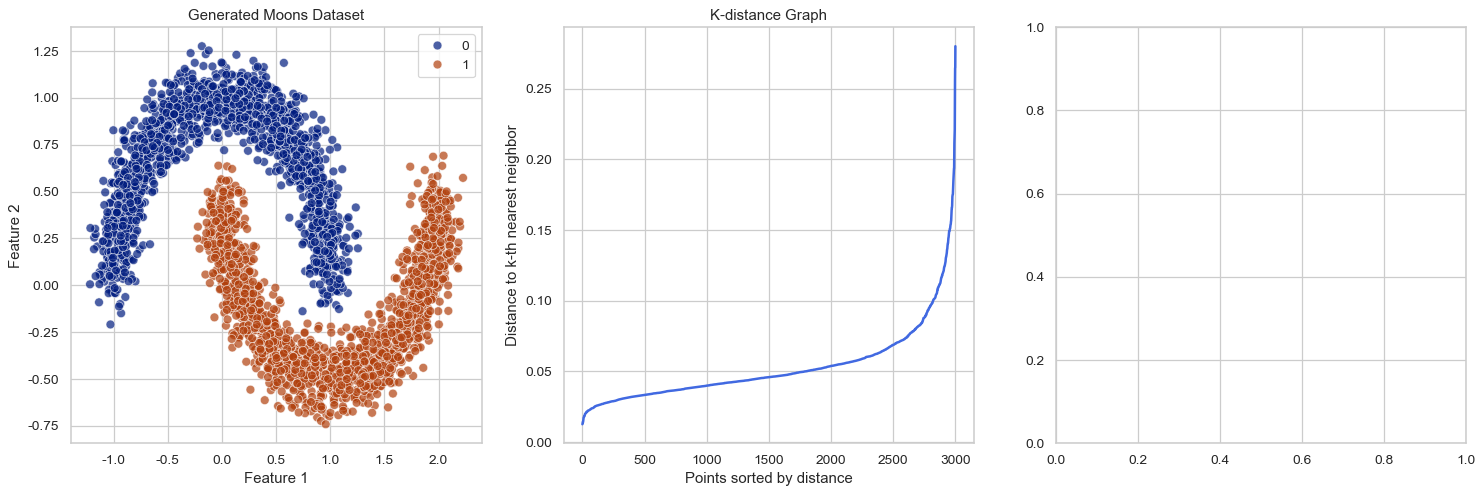

In [4]:
# 设置 MinPts（邻居数）
min_samples = 5

# 使用 NearestNeighbors 计算 K 距离
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, _ = neighbors_fit.kneighbors(X_scaled)

# 计算第 min_samples 个最近邻的距离
distances = np.sort(distances[:, -1], axis=0)

# 创建图形及其子图
fig, axs = plt.subplots(1, 3, figsize=(20, 6))

# 可视化原始数据
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='dark', s=50, alpha=0.7, ax=axs[0])
axs[0].set_title('Generated Moons Dataset')
axs[0].set_xlabel('Feature 1')
axs[0].set_ylabel('Feature 2')

# 绘制 K-距离图
axs[1].plot(distances, color='royalblue', linestyle='-', linewidth=2)
axs[1].set_title('K-distance Graph')
axs[1].set_xlabel('Points sorted by distance')
axs[1].set_ylabel('Distance to k-th nearest neighbor')

**4. 应用 DBSCAN 聚类**

选择 ε 值和 MinPts，应用 DBSCAN 聚类，并分析结果。

In [5]:
# 应用 DBSCAN 聚类
epsilon = 0.3  # 通过 K-距离图选择的值
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
labels = dbscan.fit_predict(X_scaled)

# 可视化聚类结果
scatter = sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels, palette='viridis', s=60, alpha=0.8, edgecolor='k', ax=axs[2])
axs[2].set_title('DBSCAN Clustering Results')
axs[2].set_xlabel('Feature 1')
axs[2].set_ylabel('Feature 2')
handles, labels_legend = scatter.get_legend_handles_labels()
axs[2].legend(handles, [f'Cluster {i}' for i in set(labels) if i != -1] + ['Noise'], title='Cluster Label')

# 调整布局
plt.tight_layout()
plt.show()

# 输出聚类结果的基本信息
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # -1 代表噪声点
n_noise = list(labels).count(-1)
print(f"Estimated number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")

<Figure size 576x432 with 0 Axes>

Estimated number of clusters: 1
Number of noise points: 0


![原文参考图，当前结果见代码输出](attachments/img_017.png)

**6. 评估聚类效果**

使用轮廓系数（Silhouette Score）来评估聚类效果。

In [6]:
# 计算轮廓系数
if n_clusters > 1:
    silhouette_avg = silhouette_score(X_scaled, labels)
    print(f"Silhouette Score: {silhouette_avg:.3f}")
else:
    print("Silhouette Score cannot be computed, only one cluster found or all points are noise.")

Silhouette Score cannot be computed, only one cluster found or all points are noise.


**7. 优化**

DBSCAN 的参数选择对于聚类效果至关重要。

2 点优化方式：

**1. 网格搜索**：尝试不同的 ε 和 MinPts 值组合，通过评估聚类效果来选择最佳参数。

**2. 自动选择 ε**：除了 K-距离图，还可以使用密度图等方法来自动选择 ε 值。

In [7]:
from sklearn.model_selection import ParameterGrid

# 网格搜索参数优化
param_grid = {'eps': [0.2, 0.3], 'min_samples': [3, 5]}
best_score = -1
best_params = None

for params in ParameterGrid(param_grid):
    dbscan = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = dbscan.fit_predict(X_scaled)
    if len(set(labels)) > 1:  # 仅当找到多个簇时计算轮廓系数
        score = silhouette_score(X_scaled, labels)
        if score > best_score:
            best_score = score
            best_params = params

print(f"Best Parameters: {best_params}")
print(f"Best Silhouette Score: {best_score:.3f}")

Best Parameters: {'eps': 0.2, 'min_samples': 3}
Best Silhouette Score: 0.171


咱们总结一下这个案例，我们使用 DBSCAN 对生成的月亮形状数据集进行了聚类。

DBSCAN 可以有效地处理具有复杂形状的聚类，并识别噪声，但参数选择对于聚类效果至关重要。

通过 K-距离图和网格搜索等方法，我们可以优化 DBSCAN 的性能。在大家实际实验中，根据数据的特性和需求选择合适的参数和算法是关键。

## 模型分析

在使用 DBSCAN 算法时，我们可以评估其优缺点，并将其与其他相似的聚类算法进行对比，以确定在何种情况下 DBSCAN 是优选算法，何时可能需要考虑其他算法。

### DBSCAN 算法的优缺点

#### 优点

**1. 处理噪声点**：DBSCAN 可以识别噪声点（孤立点），将它们分离出来，而不是将它们误分到某个聚类中。这在处理现实世界中的数据时尤其重要，因为数据中常常包含噪声和异常值。

**2. 无需事先指定聚类数**：与 K-Means 不同，DBSCAN 不需要用户事先指定聚类的数量，而是通过密度来自动识别聚类的数量。

#### 缺点

**1. 对参数设置敏感**：DBSCAN 的效果高度依赖于 ε（邻域距离阈值）和 MinPts（最小邻居数）这两个参数的设置。如果参数选择不当，可能导致聚类效果不佳。例如，选择的 ε 值过大或过小都会影响聚类结果。

**2. 对密度变化敏感**：DBSCAN 在处理数据密度变化较大的情况时可能会遇到困难。在数据集存在不同密度区域时，DBSCAN 可能难以找到合适的参数来处理所有区域。

**3. 计算复杂度**：在大规模数据集上，DBSCAN 的计算复杂度可能较高。尽管 DBSCAN 的时间复杂度为 $O(n \log n)$（通常基于使用 KD-Tree 或 Ball-Tree），但在处理大规模数据集时，计算和内存消耗可能会显著增加。

### 与其他相似算法的对比

| **对比项** | **K-Means** | **DBSCAN** | 层次聚类 |
|-|-|-|-|
| **聚类数的指定** | 需要预先指定聚类数量 | 不需要预先指定聚类数量 | 不需要预先指定聚类数量，自动生成树状图（层次结构） |
| **适用数据** | 适用于球形聚类，数据均匀分布 | 适用于任意形状和密度的聚类，能够识别噪声 | 适用于各种形状的数据，能够处理层次结构 |
| **优点** | 简单易用，速度较快，特别是在大数据集上。适用于球形聚类。 | 能处理任意形状的聚类，自动识别噪声，不需要指定聚类数量。 | 不需要指定聚类数，能够生成数据的层次结构，适合探索数据的关系。 |
| **缺点** | 需要预先指定聚类数，对离群点敏感，不适合非球形或不均匀密度的聚类。 | 对参数（ε和MinPts）选择敏感，处理密度变化大的数据集效果可能不好。 | 计算复杂度高，尤其在处理大数据集时不够高效，噪声点处理较弱。 |
| **计算复杂度** | 相对较低，适用于大规模数据集 | 计算复杂度中等，特别是当数据密度变化较大时可能影响效率 | 计算复杂度较高，不适合大规模数据集 |
| **噪声与异常值处理** | 对离群点敏感，可能影响聚类结果 | 对噪声和异常值较为有效，能够识别并将其排除在聚类之外。 | 对噪声点的处理较弱，可能会影响聚类效果 |
| **聚类形状** | 适用于球形或凸形聚类，适合数据分布均匀的情况 | 能处理任意形状的簇，适合复杂的数据结构，尤其是非球形聚类 | 适用于层次化结构的数据，能够揭示不同层级的聚类关系 |
| **参数调节** | 需要选择聚类数（k值），对初始质心敏感 | 需要调节邻域大小（ε）和最小样本数（MinPts），对参数选择敏感 | 需要选择距离度量和链接方法，可能有多个选择 |

### 何时选择 DBSCAN

- **数据具有复杂形状**：当数据集中的聚类具有非球形结构或不均匀密度时，DBSCAN 是一个较好的选择。
- **存在噪声点**：如果数据集中包含噪声或离群点，并且需要将这些点与主要的聚类分开，DBSCAN 能有效处理这些噪声点。
- **不确定聚类数量**：如果不清楚数据集的聚类数量，DBSCAN 可以通过其密度特性自动识别聚类的数量。

### 何时考虑其他算法

- **数据集较大且密度均匀**：如果数据集规模很大且数据密度相对均匀，K-Means 可能会更有效，因为它计算复杂度较低。
- **需要确定聚类数**：如果聚类数是已知的或可以合理估计，K-Means 或其他需要指定聚类数量的算法（如 Gaussian Mixture Models）可能更适用。
- **数据集具有层次结构**：如果数据具有明显的层次结构，并且需要分析这种层次结构，可以考虑使用层次聚类算法。

## 最后

DBSCAN 是一个强大的聚类工具，特别适用于处理复杂形状的聚类和数据中存在噪声的情况。

然而，它的性能高度依赖于参数的选择，并且在密度变化大或数据集非常大的情况下可能表现不佳。在选择聚类算法时，需要根据数据的特性和具体需求来综合考虑，选择最合适的算法。